# 🏠 House Prices — Complete Linear Regression Pipeline
### Interactive Session | Unit 8 — Data Analytics and Machine Learning

---

## What We Will Cover Today

| Step | Task |
|------|------|
| 1 | Load Data |
| 2 | Explore Data Types |
| 3 | Missing Value Analysis & Treatment |
| 4 | Outlier Analysis & Treatment |
| 5 | Feature Engineering |
| 6 | Multicollinearity Analysis (VIF) |
| 7 | Exploratory Data Analysis (EDA) |
| 8 | Train / Test Split |
| 9 | Build Model & Evaluate Metrics |
| 10 | ANOVA Results (p-values & F-score) |
| 11 | Iterate Until All p-values Significant |
| 12 | Final Prediction on Test Data |

---

## Dataset
**Kaggle — House Prices: Advanced Regression Techniques**  
https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data

### How to Download
1. Go to the link above and sign in to Kaggle
2. Click **Download All** → extract the ZIP
3. Place **`train.csv`** and **`test.csv`** in the same folder as this notebook

> **Alternative (No Kaggle Account):** We load `train.csv` from a public mirror below.

---
## ⚙️ Step 0 — Install & Import Libraries

In [1]:
# Run this cell once if any library is missing
# !pip install numpy pandas matplotlib seaborn scikit-learn statsmodels scipy

In [2]:
# ── Core ──────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ─────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# ── Statistics ────────────────────────────────────────────────────────
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

# ── Sklearn ───────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder

# ── Settings ──────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 60)
pd.set_option('display.float_format', '{:.3f}'.format)

plt.style.use('seaborn-v0_8-whitegrid')
SEED = 42

print("✓ Libraries loaded successfully")

✓ Libraries loaded successfully


---
## 📥 Step 1 — Load Data

In [4]:
# ─────────────────────────────────────────────────────────────────────
# OPTION A  — If you downloaded from Kaggle
# ─────────────────────────────────────────────────────────────────────
train_raw = pd.read_csv('data/train.csv')
test_raw  = pd.read_csv('data/test.csv')


# Keep a clean copy for reference
df = train_raw.copy()

print(f"Train shape : {train_raw.shape}")
print(f"Test  shape : {test_raw.shape}")

df.head()

Train shape : (1460, 81)
Test  shape : (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.000,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.000,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.000,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.000,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.000,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.000,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.000,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.000,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.000,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.000,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.000,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.000,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.000,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.000,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.000,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
# Target variable
TARGET = 'SalePrice'

print("Target (SalePrice) statistics:")
print(df[TARGET].describe())
print(f"\nAre there nulls in target? {df[TARGET].isnull().sum()}")

Target (SalePrice) statistics:
count     1460.000
mean    180921.196
std      79442.503
min      34900.000
25%     129975.000
50%     163000.000
75%     214000.000
max     755000.000
Name: SalePrice, dtype: float64

Are there nulls in target? 0


---
## 🔍 Step 2 — Explore Data Types

In [6]:
# How many numerical vs categorical columns?
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Total columns  : {df.shape[1]}")
print(f"Numerical cols : {len(num_cols)} → {num_cols[:10]} ...")
print(f"Categorical cols: {len(cat_cols)} → {cat_cols[:10]} ...")

Total columns  : 81
Numerical cols : 38 → ['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1'] ...
Categorical cols: 43 → ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1'] ...


In [7]:
# Full dtype overview
dtype_df = pd.DataFrame({
    'Column'  : df.columns,
    'DType'   : df.dtypes.values,
    'Nunique' : df.nunique().values,
    'Sample'  : [df[c].dropna().iloc[0] if df[c].dropna().shape[0] > 0 else None
                 for c in df.columns]
})
dtype_df

,Column,DType,Nunique,Sample
0,Id,int64,1460,1
1,MSSubClass,int64,15,60
2,MSZoning,object,5,RL
3,LotFrontage,float64,110,65.000
4,LotArea,int64,1073,8450
...,...,...,...,...
76,MoSold,int64,12,2
77,YrSold,int64,5,2008
78,SaleType,object,9,WD
79,SaleCondition,object,6,Normal


---
## 🩺 Step 3 — Missing Value Analysis & Treatment

### Rule of Thumb
| Missing % | Action |
|-----------|--------|
| > 40 %    | **Drop the column** — too much data lost |
| 5 – 40 %  | **Impute** — mean/median (numeric), mode or 'None' (categorical) |
| < 5 %     | **Impute** with mean/median/mode |

**Why?**  
Most ML algorithms cannot work with NaN values. Filling them properly preserves information instead of discarding whole rows.

In [8]:
# ── 3.1  Calculate missing percentage per column ─────────────────────
missing = (
    df.isnull().sum()
      .rename('missing_count')
      .to_frame()
)
missing['missing_pct'] = (missing['missing_count'] / len(df)) * 100
missing = missing[missing['missing_count'] > 0].sort_values('missing_pct', ascending=False)

print(f"Columns with missing values: {len(missing)} out of {df.shape[1]}\n")
print(missing)

Columns with missing values: 19 out of 81

              missing_count  missing_pct
PoolQC                 1453       99.521
MiscFeature            1406       96.301
Alley                  1369       93.767
Fence                  1179       80.753
MasVnrType              872       59.726
FireplaceQu             690       47.260
LotFrontage             259       17.740
GarageType               81        5.548
GarageYrBlt              81        5.548
GarageFinish             81        5.548
GarageQual               81        5.548
GarageCond               81        5.548
BsmtExposure             38        2.603
BsmtFinType2             38        2.603
BsmtQual                 37        2.534
BsmtCond                 37        2.534
BsmtFinType1             37        2.534
MasVnrArea                8        0.548
Electrical                1        0.068


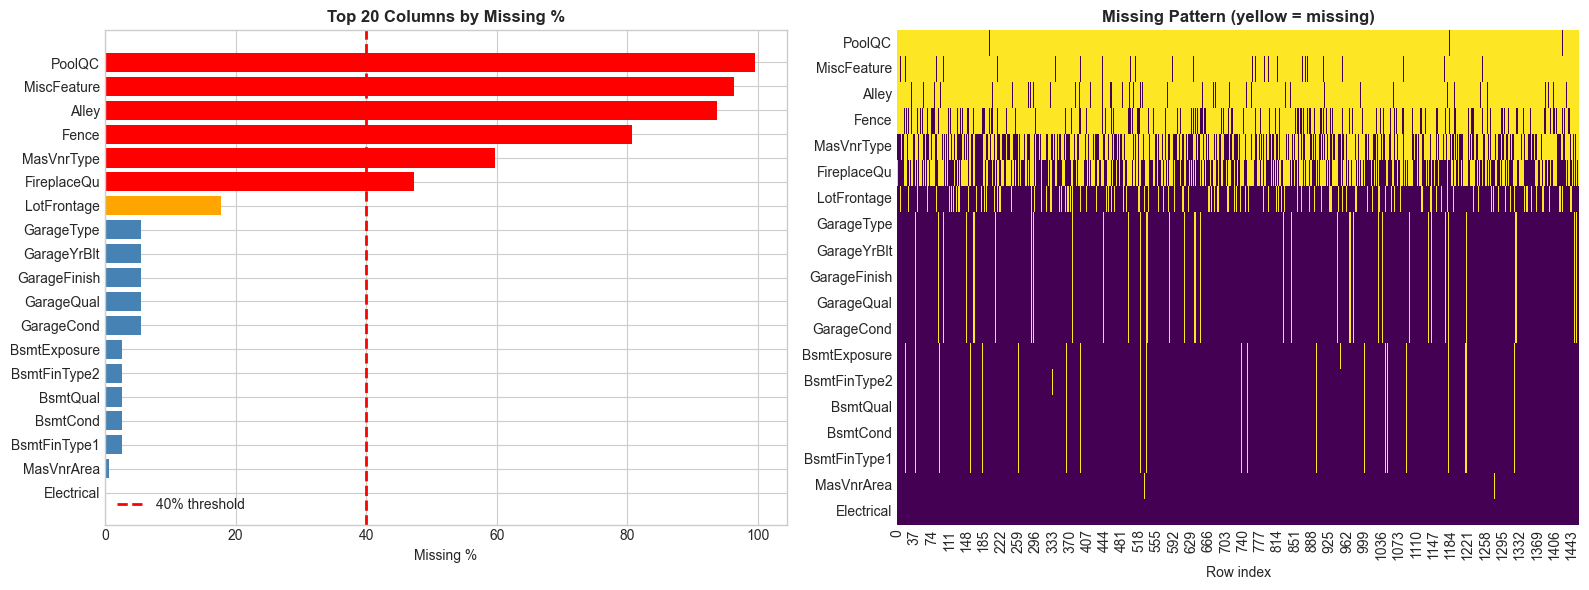

In [9]:
# ── 3.2  Visualise missing values ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart — top 20 columns
top20 = missing.head(20)
colors = ['red' if x > 40 else 'orange' if x > 10 else 'steelblue'
          for x in top20['missing_pct']]
axes[0].barh(top20.index, top20['missing_pct'], color=colors)
axes[0].axvline(40, color='red', linestyle='--', linewidth=2, label='40% threshold')
axes[0].set_xlabel('Missing %')
axes[0].set_title('Top 20 Columns by Missing %', fontweight='bold')
axes[0].legend()
axes[0].invert_yaxis()

# Heatmap of missing pattern
sample_cols = missing.head(30).index.tolist()
sns.heatmap(df[sample_cols].isnull().T,
            cbar=False, cmap='viridis',
            yticklabels=True, ax=axes[1])
axes[1].set_title('Missing Pattern (yellow = missing)', fontweight='bold')
axes[1].set_xlabel('Row index')

plt.tight_layout()
plt.show()

In [10]:
# ── 3.3  Drop columns where missing > 40 % ───────────────────────────
DROP_THRESHOLD = 40
cols_to_drop = missing[missing['missing_pct'] > DROP_THRESHOLD].index.tolist()

print(f"Columns to DROP (>{DROP_THRESHOLD}% missing):")
for c in cols_to_drop:
    print(f"  {c:20s}  {missing.loc[c,'missing_pct']:.1f}% missing")

df.drop(columns=cols_to_drop, inplace=True)
print(f"\nShape after dropping: {df.shape}")

Columns to DROP (>40% missing):
  PoolQC                99.5% missing
  MiscFeature           96.3% missing
  Alley                 93.8% missing
  Fence                 80.8% missing
  MasVnrType            59.7% missing
  FireplaceQu           47.3% missing

Shape after dropping: (1460, 75)


In [11]:
# ── 3.4  Impute remaining missing values ─────────────────────────────

# Refresh lists after dropping
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

# Remove target from numerical list
num_cols = [c for c in num_cols if c != TARGET]

# ──  Numerical: fill with MEDIAN  (robust to outliers vs mean)
# ──  NOTE: For year columns use mode; for continuous use median
year_cols = [c for c in num_cols if 'Year' in c or 'Yr' in c]
cont_num  = [c for c in num_cols if c not in year_cols]

for col in cont_num:
    n = df[col].isnull().sum()
    if n > 0:
        df[col].fillna(df[col].median(), inplace=True)
        print(f"  [NUMERIC-MEDIAN]  {col:30s}  filled {n} nulls")

for col in year_cols:
    n = df[col].isnull().sum()
    if n > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)
        print(f"  [YEAR-MODE]       {col:30s}  filled {n} nulls")

# ──  Categorical:
#     If the feature represents ABSENCE (e.g. no garage), use 'None'
#     Otherwise, use MODE
absence_cols = ['GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
                'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
                'BsmtFinType2', 'MasVnrType', 'FireplaceQu']

for col in cat_cols:
    if col in df.columns:
        n = df[col].isnull().sum()
        if n > 0:
            if col in absence_cols:
                df[col].fillna('None', inplace=True)
                print(f"  [CAT-NONE]        {col:30s}  filled {n} nulls")
            else:
                df[col].fillna(df[col].mode()[0], inplace=True)
                print(f"  [CAT-MODE]        {col:30s}  filled {n} nulls")

# Verify
remaining = df.isnull().sum().sum()
print(f"\n✓ Total remaining nulls: {remaining}")

  [NUMERIC-MEDIAN]  LotFrontage                     filled 259 nulls
  [NUMERIC-MEDIAN]  MasVnrArea                      filled 8 nulls
  [YEAR-MODE]       GarageYrBlt                     filled 81 nulls
  [CAT-NONE]        BsmtQual                        filled 37 nulls
  [CAT-NONE]        BsmtCond                        filled 37 nulls
  [CAT-NONE]        BsmtExposure                    filled 38 nulls
  [CAT-NONE]        BsmtFinType1                    filled 37 nulls
  [CAT-NONE]        BsmtFinType2                    filled 38 nulls
  [CAT-MODE]        Electrical                      filled 1 nulls
  [CAT-NONE]        GarageType                      filled 81 nulls
  [CAT-NONE]        GarageFinish                    filled 81 nulls
  [CAT-NONE]        GarageQual                      filled 81 nulls
  [CAT-NONE]        GarageCond                      filled 81 nulls

✓ Total remaining nulls: 0


---
## 📦 Step 4 — Outlier Analysis & Treatment

### Methods
| Method | When to Use | What it Detects |
|--------|-------------|----------------|
| **IQR (Box-plot)** | Skewed data | Mild & extreme outliers |
| **Z-score** | Normal data | Points far from mean |

### Treatment: Winsorisation (Capping)
Replace extreme values with the **1.5×IQR boundary** — keeps the row but reduces the outlier's influence.

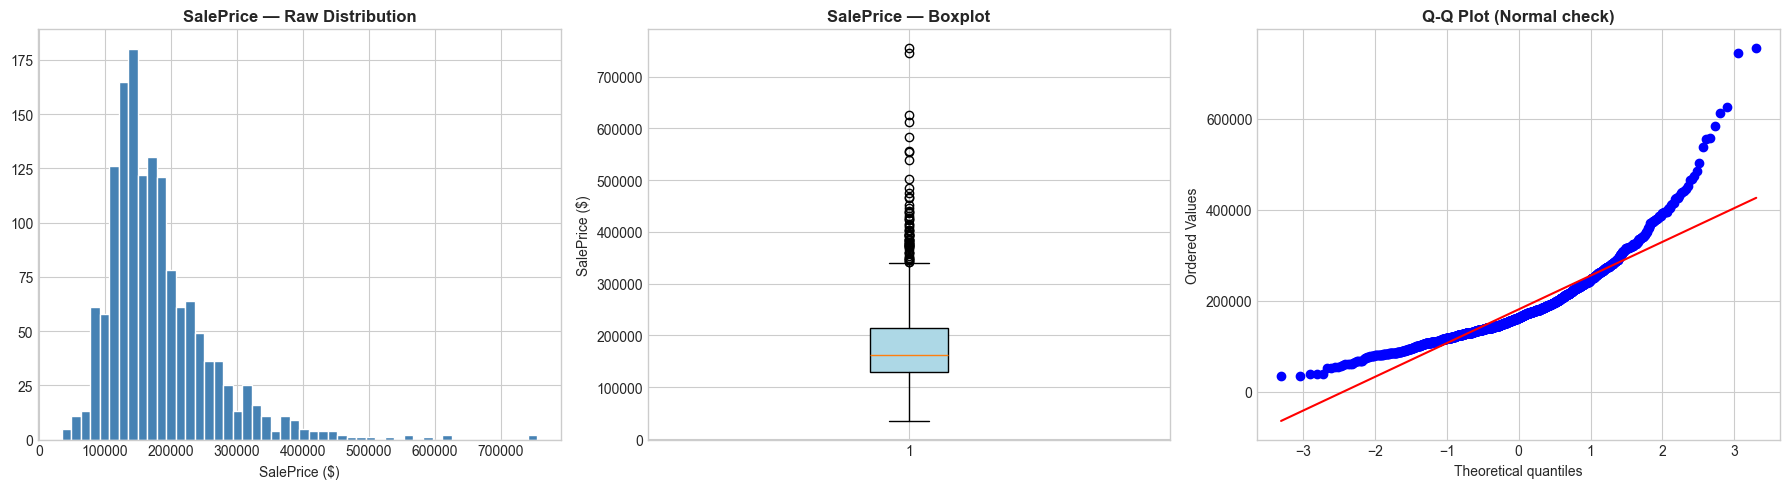

SalePrice Skewness : 1.8829  (>1 = right-skewed, apply log transform)


In [12]:
# ── 4.1  Visualise target distribution ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram
axes[0].hist(df[TARGET], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('SalePrice — Raw Distribution', fontweight='bold')
axes[0].set_xlabel('SalePrice ($)')

# Boxplot
axes[1].boxplot(df[TARGET], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
axes[1].set_title('SalePrice — Boxplot', fontweight='bold')
axes[1].set_ylabel('SalePrice ($)')

# Q-Q plot  (normal distribution check)
stats.probplot(df[TARGET], dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot (Normal check)', fontweight='bold')

plt.tight_layout()
plt.show()

# Skewness
print(f"SalePrice Skewness : {df[TARGET].skew():.4f}  "
      f"(>1 = right-skewed, apply log transform)")

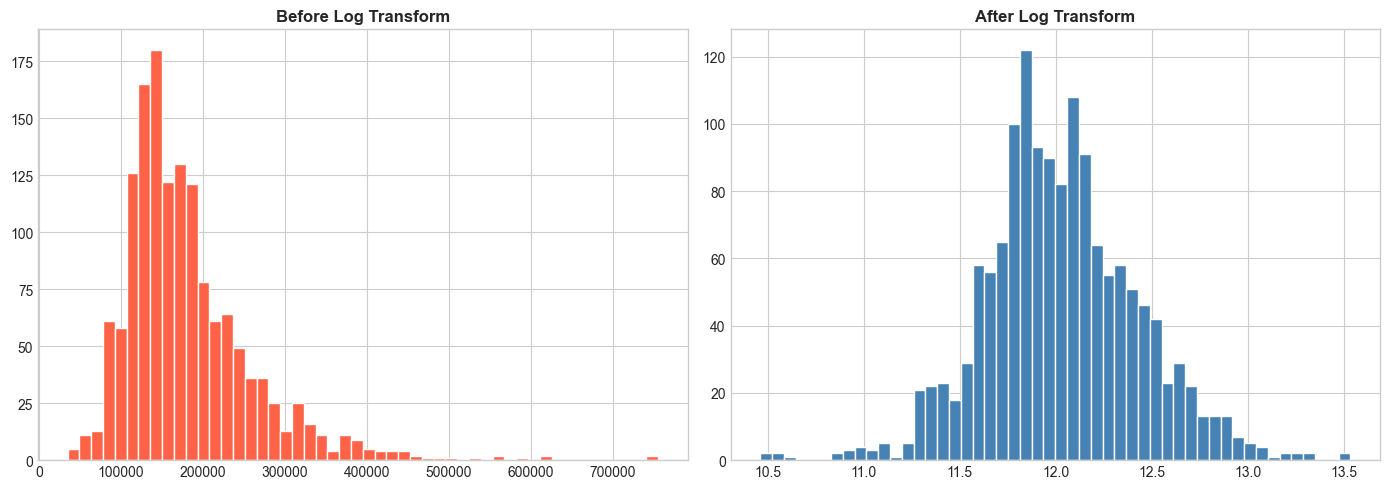

Skewness BEFORE: 1.8829
Skewness AFTER : 0.1213  (closer to 0 = better)


In [13]:
# ── 4.2  Log-transform the target  (fixes right skew) ────────────────
#   log(SalePrice) makes it more normally distributed
#   → better for Linear Regression assumptions

df['LogSalePrice'] = np.log1p(df[TARGET])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df[TARGET],        bins=50, color='tomato',    edgecolor='white')
axes[0].set_title('Before Log Transform', fontweight='bold')
axes[1].hist(df['LogSalePrice'], bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('After Log Transform', fontweight='bold')
plt.tight_layout(); plt.show()

print(f"Skewness BEFORE: {df[TARGET].skew():.4f}")
print(f"Skewness AFTER : {df['LogSalePrice'].skew():.4f}  (closer to 0 = better)")

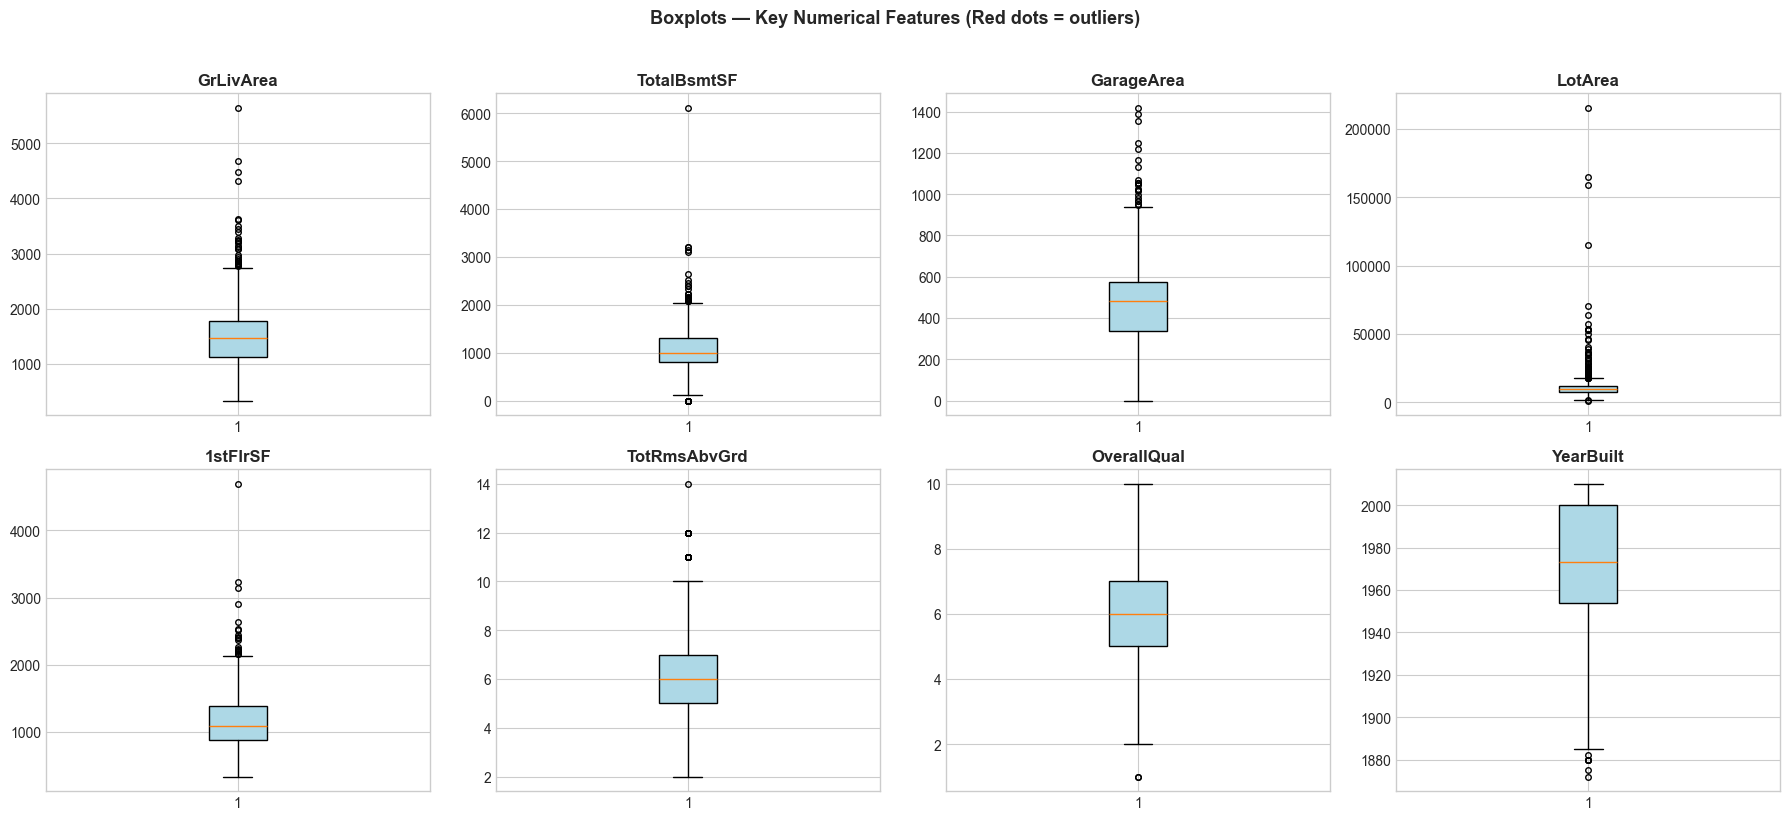

In [14]:
# ── 4.3  Outlier detection with IQR ─────────────────────────────────
#   Check top 10 most important numeric features for outliers

key_num = ['GrLivArea', 'TotalBsmtSF', 'GarageArea', 'LotArea',
           '1stFlrSF', 'TotRmsAbvGrd', 'OverallQual', 'YearBuilt']

# Filter to columns that exist
key_num = [c for c in key_num if c in df.columns]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(key_num):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightblue'),
                    flierprops=dict(marker='o', color='red', markersize=4))
    axes[i].set_title(col, fontweight='bold')

plt.suptitle('Boxplots — Key Numerical Features (Red dots = outliers)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

In [15]:
# ── 4.4  Winsorise (cap) outliers using 1.5 × IQR ───────────────────
#   This is CAPPING — we do NOT delete rows
#   Any value below lower fence → set to lower fence
#   Any value above upper fence → set to upper fence

def winsorise(series, factor=1.5):
    """Cap values at 1.5*IQR boundaries."""
    Q1  = series.quantile(0.25)
    Q3  = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - factor * IQR
    upper = Q3 + factor * IQR
    return series.clip(lower=lower, upper=upper)

# Apply only to continuous numeric columns (not ordinal/binary)
winsorise_cols = ['GrLivArea', 'TotalBsmtSF', 'GarageArea', 'LotArea', '1stFlrSF']
winsorise_cols = [c for c in winsorise_cols if c in df.columns]

print("Winsorising outliers...")
for col in winsorise_cols:
    before = df[col].max()
    df[col] = winsorise(df[col])
    after  = df[col].max()
    print(f"  {col:20s}  max before: {before:8.1f}  →  max after: {after:8.1f}")

print("\n✓ Outlier treatment complete")

Winsorising outliers...
  GrLivArea             max before:   5642.0  →  max after:   2747.6
  TotalBsmtSF           max before:   6110.0  →  max after:   2052.0
  GarageArea            max before:   1418.0  →  max after:    938.2
  LotArea               max before: 215245.0  →  max after:  17673.5
  1stFlrSF              max before:   4692.0  →  max after:   2155.1

✓ Outlier treatment complete


---
## 🔧 Step 5 — Feature Engineering

We create new features that **combine existing information** in ways that are more predictive of SalePrice.

In [16]:
# ── 5.1  Create new meaningful features ──────────────────────────────

# Total living area
if 'GrLivArea' in df.columns and 'TotalBsmtSF' in df.columns:
    df['TotalSF'] = df['GrLivArea'] + df['TotalBsmtSF']

# Age of house at time of sale
if 'YearBuilt' in df.columns and 'YrSold' in df.columns:
    df['HouseAge']    = df['YrSold'] - df['YearBuilt']
    df['Renovated']   = (df['YearRemodAdd'] != df['YearBuilt']).astype(int)

# Total bathrooms
bath_cols = ['FullBath', 'HalfBath', 'BsmtFullBath', 'BsmtHalfBath']
bath_cols = [c for c in bath_cols if c in df.columns]
if bath_cols:
    df['TotalBathrooms'] = (df.get('FullBath', 0)
                           + df.get('HalfBath', 0) * 0.5
                           + df.get('BsmtFullBath', 0)
                           + df.get('BsmtHalfBath', 0) * 0.5)

# Has pool, fireplace, garage flags
if 'PoolArea'  in df.columns: df['HasPool']      = (df['PoolArea'] > 0).astype(int)
if 'Fireplaces' in df.columns: df['HasFireplace'] = (df['Fireplaces'] > 0).astype(int)
if 'GarageArea' in df.columns: df['HasGarage']   = (df['GarageArea'] > 0).astype(int)

# Porch total area
porch_cols = ['OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch']
porch_cols = [c for c in porch_cols if c in df.columns]
if porch_cols:
    df['TotalPorchSF'] = df[porch_cols].sum(axis=1)

new_feats = ['TotalSF', 'HouseAge', 'Renovated', 'TotalBathrooms',
             'HasPool', 'HasFireplace', 'HasGarage', 'TotalPorchSF']
new_feats = [f for f in new_feats if f in df.columns]

print("New features created:")
for f in new_feats:
    print(f"  {f:20s}  — {df[f].describe()[['min','mean','max']].to_dict()}")

New features created:
  TotalSF               — {'min': 376.0, 'mean': 2553.9906678082193, 'max': 4799.625}
  HouseAge              — {'min': 0.0, 'mean': 36.54794520547945, 'max': 136.0}
  Renovated             — {'min': 0.0, 'mean': 0.4767123287671233, 'max': 1.0}
  TotalBathrooms        — {'min': 1.0, 'mean': 2.210616438356164, 'max': 6.0}
  HasPool               — {'min': 0.0, 'mean': 0.004794520547945206, 'max': 1.0}
  HasFireplace          — {'min': 0.0, 'mean': 0.5273972602739726, 'max': 1.0}
  HasGarage             — {'min': 0.0, 'mean': 0.9445205479452055, 'max': 1.0}
  TotalPorchSF          — {'min': 0.0, 'mean': 87.08493150684932, 'max': 1027.0}


In [17]:
# ── 5.2  Encode Categorical columns ──────────────────────────────────
#   We use Label Encoding (ordinal). For production use OneHotEncoding.

cat_cols_now = df.select_dtypes(include='object').columns.tolist()

le = LabelEncoder()
for col in cat_cols_now:
    df[col] = le.fit_transform(df[col].astype(str))

print(f"Encoded {len(cat_cols_now)} categorical columns")
print("Shape now:", df.shape)

Encoded 37 categorical columns
Shape now: (1460, 84)


---
## 📊 Step 6 — Multicollinearity Analysis (VIF)

**What is Multicollinearity?**  
When two or more predictor variables are highly correlated with each other, it makes it hard for the model to determine the individual effect of each predictor.

**Variance Inflation Factor (VIF)**  
- VIF = 1 → No correlation  
- VIF = 1–5 → Moderate (acceptable)  
- VIF > 5 → **Concerning**  
- VIF > 10 → **Drop the column**

In [18]:
# ── 6.1  Select numeric predictors for VIF ───────────────────────────
# Use only numeric columns; exclude target
exclude = [TARGET, 'LogSalePrice', 'Id']
pred_cols = [c for c in df.select_dtypes(include=np.number).columns
             if c not in exclude]

print(f"Number of predictors for VIF analysis: {len(pred_cols)}")

Number of predictors for VIF analysis: 81


In [19]:
def compute_vif(dataframe, columns):
    """Calculate VIF for all columns and return a sorted DataFrame."""
    X = dataframe[columns].dropna()
    X = sm.add_constant(X)                     # add intercept
    vif_data = pd.DataFrame()
    vif_data['Feature'] = columns
    vif_data['VIF'] = [
        variance_inflation_factor(X.values, i + 1)   # +1 skips constant
        for i in range(len(columns))
    ]
    return vif_data.sort_values('VIF', ascending=False)


def drop_high_vif(dataframe, columns, threshold=10, verbose=True):
    """
    Iteratively drop the column with highest VIF
    until all remaining VIFs are below the threshold.
    Returns the cleaned column list.
    """
    cols = columns.copy()
    iteration = 1

    while True:
        vif_df = compute_vif(dataframe, cols)
        max_vif = vif_df['VIF'].max()

        if max_vif < threshold:
            if verbose:
                print(f"\n✓ All VIF values < {threshold}. No more columns to drop.")
            break

        drop_col = vif_df.iloc[0]['Feature']
        if verbose:
            print(f"Iteration {iteration:2d} | Drop '{drop_col}' (VIF = {max_vif:.2f})")
        cols.remove(drop_col)
        iteration += 1

    return cols, vif_df


# Run VIF reduction
print("Starting VIF reduction (threshold = 10)...\n")
final_cols, final_vif = drop_high_vif(df, pred_cols, threshold=10)
print(f"\nFeatures remaining after VIF: {len(final_cols)} / {len(pred_cols)}")

Starting VIF reduction (threshold = 10)...

Iteration  1 | Drop 'YearBuilt' (VIF = inf)
Iteration  2 | Drop 'EnclosedPorch' (VIF = inf)
Iteration  3 | Drop 'TotalBathrooms' (VIF = inf)
Iteration  4 | Drop 'TotalBsmtSF' (VIF = inf)
Iteration  5 | Drop 'TotalSF' (VIF = 79.35)
Iteration  6 | Drop 'HasPool' (VIF = 64.46)
Iteration  7 | Drop 'GrLivArea' (VIF = 44.79)

✓ All VIF values < 10. No more columns to drop.

Features remaining after VIF: 74 / 81



Final VIF values (all should be < 10):
      Feature   VIF
     HouseAge 8.823
     1stFlrSF 6.769
   GarageCars 6.764
   GarageArea 6.759
     2ndFlrSF 6.645
   Fireplaces 6.438
 HasFireplace 6.291
   BsmtFinSF1 5.614
   MSSubClass 5.342
 TotRmsAbvGrd 5.185
     BldgType 4.871
  GarageYrBlt 4.859
    BsmtUnfSF 4.643
    HasGarage 4.317
  Exterior2nd 4.035
  Exterior1st 4.029
  OverallQual 3.938
 TotalPorchSF 3.912
     FullBath 3.175
 YearRemodAdd 3.168
 BedroomAbvGr 2.702
    ExterQual 2.691
  OpenPorchSF 2.623
      LotArea 2.535
     BsmtQual 2.520
   BsmtFinSF2 2.501
 BsmtFullBath 2.360
     HalfBath 2.355
   HouseStyle 2.307
 BsmtFinType2 2.295
   GarageType 2.188
   GarageCond 2.071
   Foundation 2.061
  KitchenQual 2.054
   GarageQual 2.023
  ScreenPorch 1.991
 BsmtFinType1 1.971
  OverallCond 1.967
  LotFrontage 1.838
 GarageFinish 1.834
 KitchenAbvGr 1.796
   CentralAir 1.784
    Renovated 1.759
    HeatingQC 1.650
 BsmtExposure 1.548
   PavedDrive 1.531
   MasVnrArea 1.519


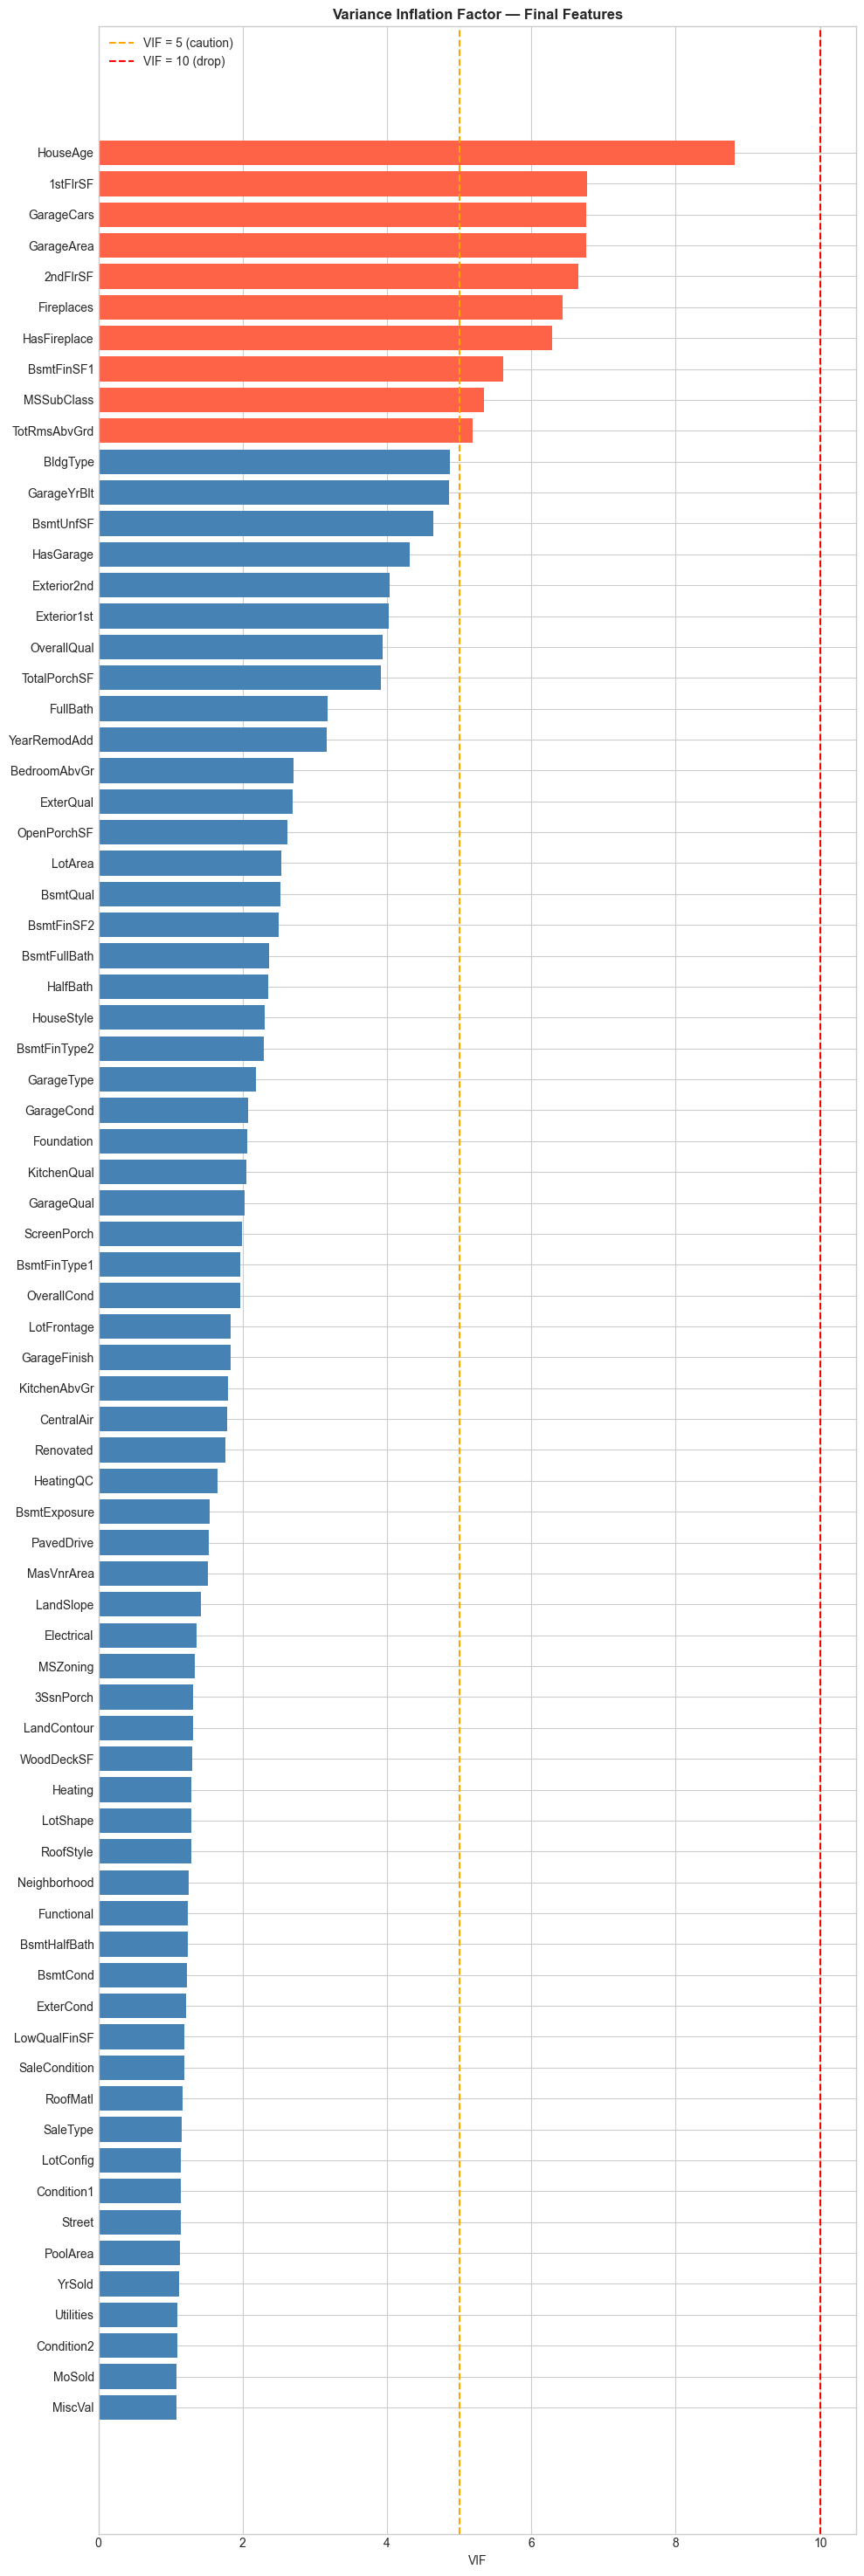

In [20]:
# ── 6.2  Show final VIF values ───────────────────────────────────────
print("\nFinal VIF values (all should be < 10):")
print(final_vif.to_string(index=False))

# ── 6.3  Visualise final VIF ─────────────────────────────────────────
plt.figure(figsize=(10, max(5, len(final_vif) * 0.4)))
colors = ['tomato' if v > 5 else 'steelblue' for v in final_vif['VIF']]
plt.barh(final_vif['Feature'], final_vif['VIF'], color=colors)
plt.axvline(5,  color='orange', linestyle='--', label='VIF = 5 (caution)')
plt.axvline(10, color='red',    linestyle='--', label='VIF = 10 (drop)')
plt.xlabel('VIF')
plt.title('Variance Inflation Factor — Final Features', fontweight='bold')
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

---
## 🔎 Step 7 — Exploratory Data Analysis (EDA)

In [21]:
# ── 7.1  Correlation with Target ─────────────────────────────────────
corr_with_target = (
    df[final_cols + ['LogSalePrice']]
    .corr()['LogSalePrice']
    .drop('LogSalePrice')
    .sort_values(key=abs, ascending=False)
)

print("Top 20 features most correlated with LogSalePrice:")
print(corr_with_target.head(20))

Top 20 features most correlated with LogSalePrice:
OverallQual     0.817
GarageCars      0.681
GarageArea      0.661
1stFlrSF        0.618
FullBath        0.595
HouseAge       -0.587
ExterQual      -0.582
BsmtQual       -0.577
YearRemodAdd    0.566
TotRmsAbvGrd    0.534
KitchenQual    -0.534
HasFireplace    0.510
GarageType     -0.503
Fireplaces      0.489
LotArea         0.438
MasVnrArea      0.427
HeatingQC      -0.426
GarageFinish   -0.417
Foundation      0.412
GarageYrBlt     0.406
Name: LogSalePrice, dtype: float64


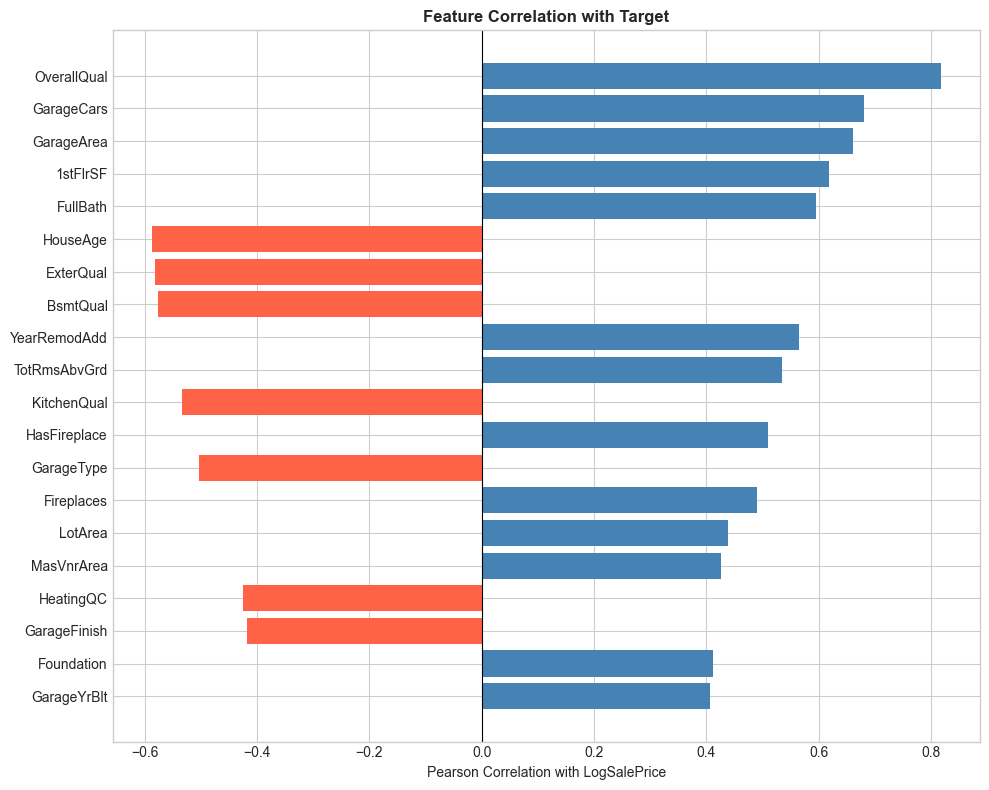

In [22]:
# ── 7.2  Correlation bar chart ───────────────────────────────────────
top_corr = corr_with_target.head(20)

colors = ['steelblue' if v > 0 else 'tomato' for v in top_corr.values]
plt.figure(figsize=(10, 8))
plt.barh(top_corr.index, top_corr.values, color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Pearson Correlation with LogSalePrice')
plt.title('Feature Correlation with Target', fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

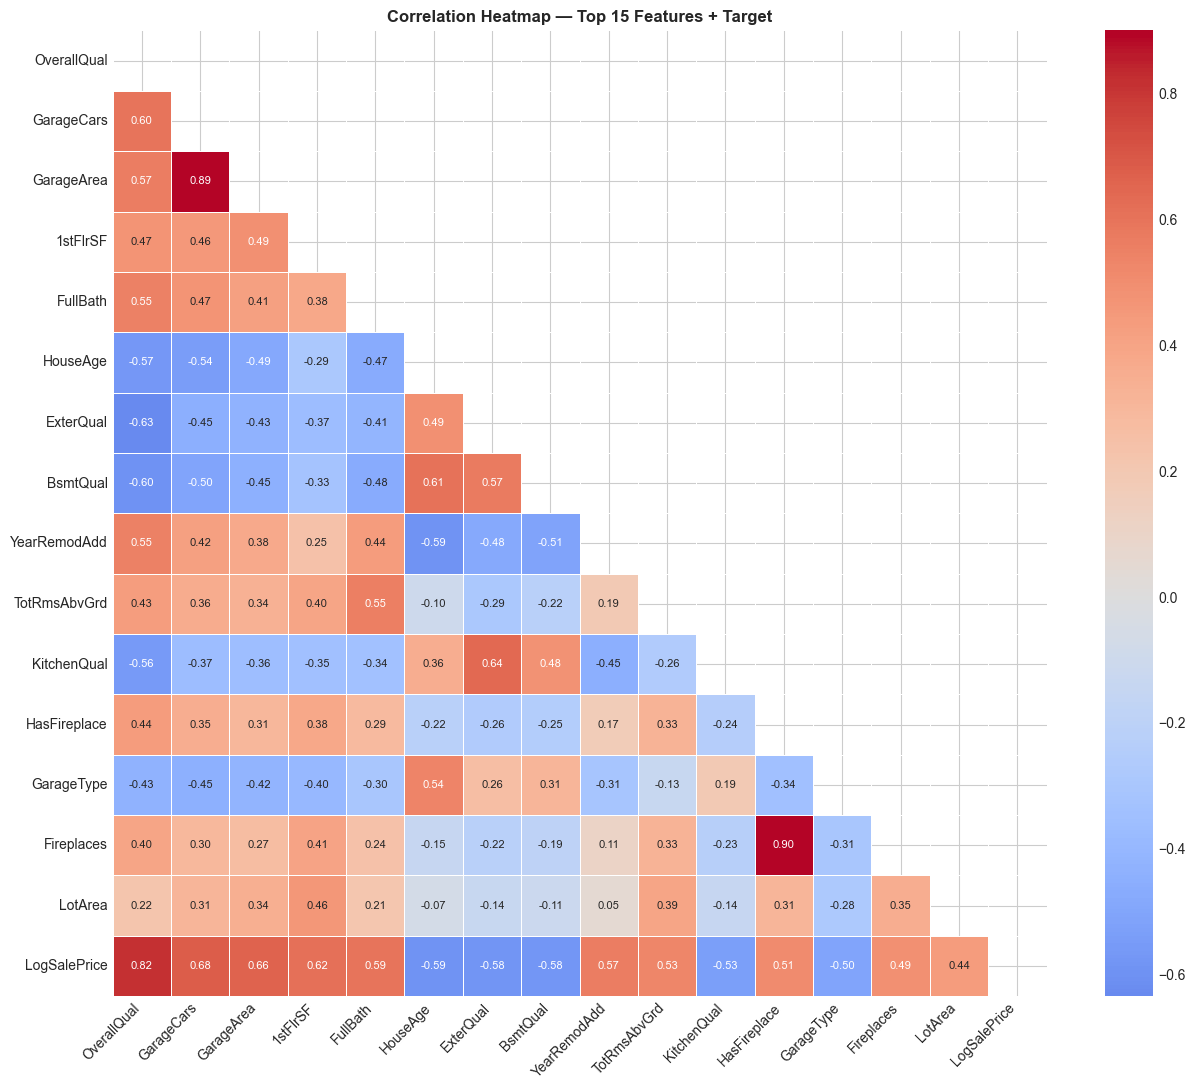

In [24]:
# ── 7.3  Correlation Heatmap — Top 15 features ───────────────────────
top15 = corr_with_target.head(15).index.tolist() + ['LogSalePrice']

plt.figure(figsize=(13, 11))
corr_matrix = df[top15].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5,
    annot_kws={'size': 8}
)
plt.title('Correlation Heatmap — Top 15 Features + Target', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

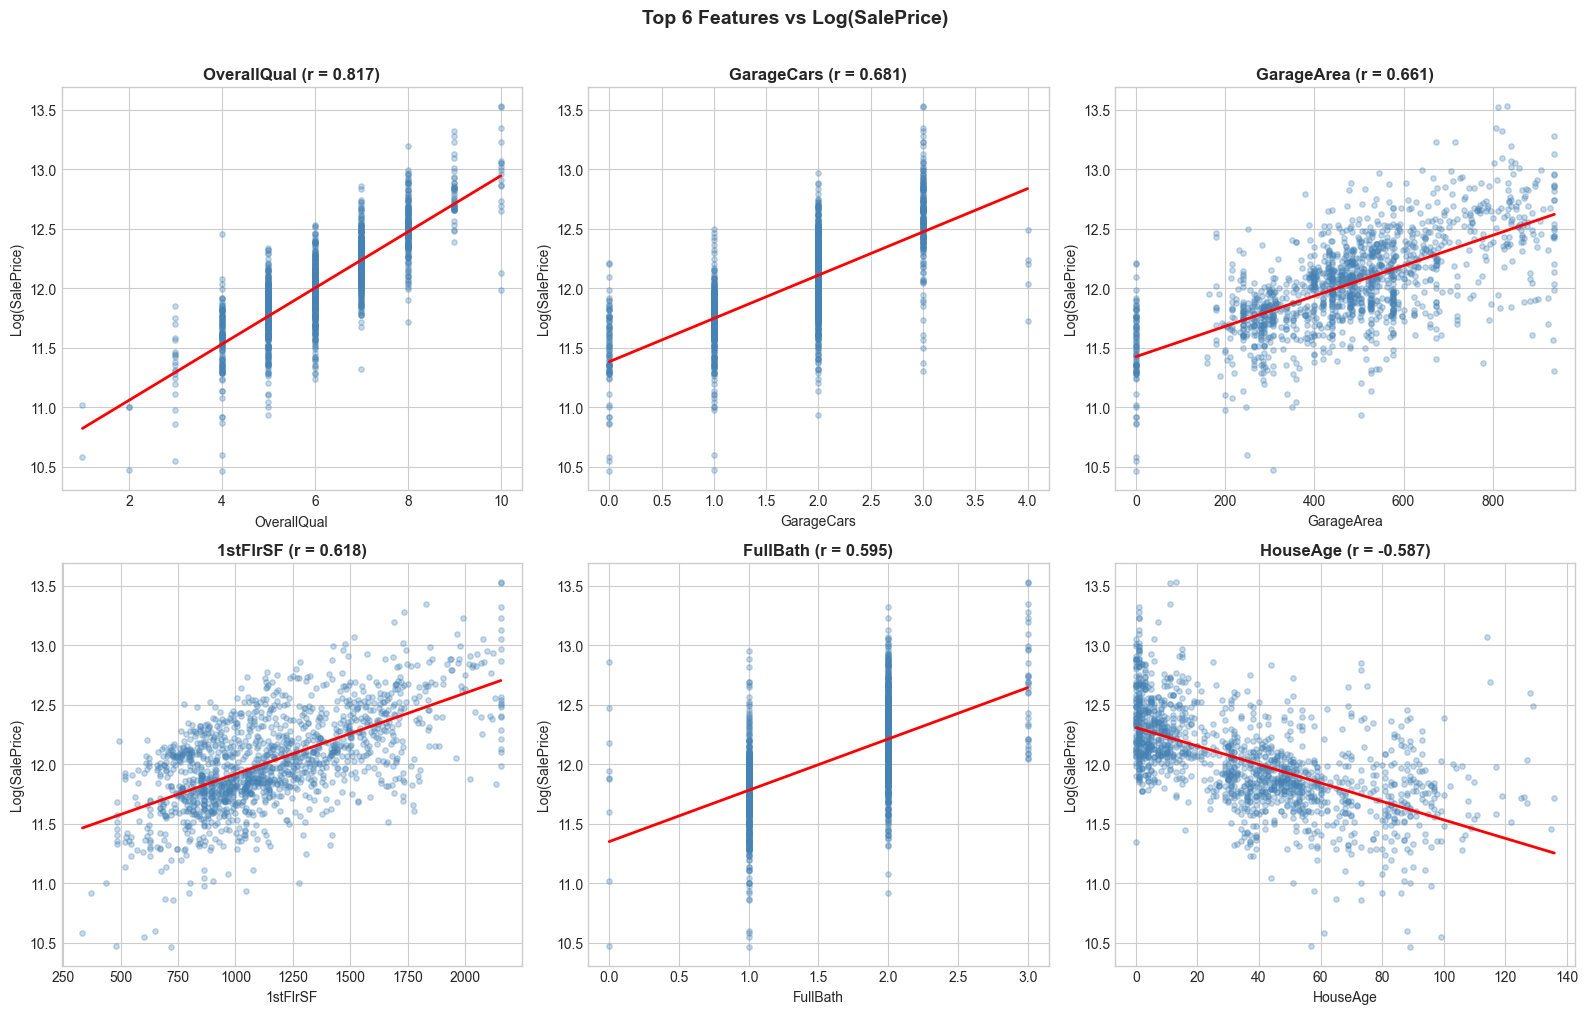

In [25]:
# ── 7.4  Scatter plots — Top 6 features vs LogSalePrice ──────────────
top6 = corr_with_target.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(top6):
    axes[i].scatter(df[col], df['LogSalePrice'],
                    alpha=0.3, s=15, color='steelblue')
    # Add regression line
    m, b = np.polyfit(df[col], df['LogSalePrice'], 1)
    xline = np.linspace(df[col].min(), df[col].max(), 100)
    axes[i].plot(xline, m * xline + b, color='red', linewidth=2)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Log(SalePrice)')
    axes[i].set_title(f'{col} (r = {corr_with_target[col]:.3f})',
                      fontweight='bold')

plt.suptitle('Top 6 Features vs Log(SalePrice)', fontsize=14,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## ✂️ Step 8 — Train / Test Split

In [26]:
# ── 8.1  Define features and target ──────────────────────────────────
# Use the surviving features from VIF + keep top correlated ones
# Select top 20 by correlation for a lean, interpretable model
TOP_N = 20
selected_features = corr_with_target.head(TOP_N).index.tolist()
# Ensure they exist in final_cols (passed VIF)
selected_features = [f for f in selected_features if f in final_cols]

X = df[selected_features]
y = df['LogSalePrice']   # Log-transformed target

print(f"Features selected : {len(selected_features)}")
print(f"Feature names     : {selected_features}")
print(f"\nX shape : {X.shape}")
print(f"y shape : {y.shape}")

Features selected : 20
Feature names     : ['OverallQual', 'GarageCars', 'GarageArea', '1stFlrSF', 'FullBath', 'HouseAge', 'ExterQual', 'BsmtQual', 'YearRemodAdd', 'TotRmsAbvGrd', 'KitchenQual', 'HasFireplace', 'GarageType', 'Fireplaces', 'LotArea', 'MasVnrArea', 'HeatingQC', 'GarageFinish', 'Foundation', 'GarageYrBlt']

X shape : (1460, 20)
y shape : (1460,)


In [27]:
# ── 8.2  Split 80 % train / 20 % test ────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED
)

print(f"X_train : {X_train.shape}   y_train : {y_train.shape}")
print(f"X_test  : {X_test.shape}    y_test  : {y_test.shape}")
print(f"\nTrain %  : {len(X_train)/len(X)*100:.1f}%")
print(f"Test  %  : {len(X_test)/len(X)*100:.1f}%")

X_train : (1168, 20)   y_train : (1168,)
X_test  : (292, 20)    y_test  : (292,)

Train %  : 80.0%
Test  %  : 20.0%


---
## 🤖 Step 9 — Build Model & Evaluate Metrics

We use **two libraries**:
- `sklearn` → quick model, metrics (R², RMSE, MAE)
- `statsmodels OLS` → statistical output (p-values, F-score, confidence intervals)

In [28]:
# ── 9.1  Sklearn model ────────────────────────────────────────────────
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_train = lr.predict(X_train)
y_pred_test  = lr.predict(X_test)

def evaluate(y_true, y_pred, label='Set'):
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    # Convert back from log space for interpretable RMSE
    rmse_dollars = np.sqrt(mean_squared_error(
        np.expm1(y_true), np.expm1(y_pred)
    ))
    print(f"  [{label}]")
    print(f"    R²   = {r2:.4f}  (1 = perfect, >0.80 = good)")
    print(f"    RMSE = {rmse:.4f} (log scale)")
    print(f"    MAE  = {mae:.4f} (log scale)")
    print(f"    RMSE = ${rmse_dollars:,.0f}  (actual $)")
    return r2, rmse, mae

print("=" * 50)
print("Model Performance")
print("=" * 50)
r2_train, _, _ = evaluate(y_train, y_pred_train, 'TRAIN')
print()
r2_test,  _, _ = evaluate(y_test,  y_pred_test,  'TEST')
print()
gap = r2_train - r2_test
print(f"  Overfitting gap (Train R² − Test R²) = {gap:.4f}")
print(f"  {'⚠️ Possible overfit' if gap > 0.05 else '✓ Acceptable gap'}")

Model Performance
  [TRAIN]
    R²   = 0.8403  (1 = perfect, >0.80 = good)
    RMSE = 0.1560 (log scale)
    MAE  = 0.1114 (log scale)
    RMSE = $33,283  (actual $)

  [TEST]
    R²   = 0.8486  (1 = perfect, >0.80 = good)
    RMSE = 0.1681 (log scale)
    MAE  = 0.1214 (log scale)
    RMSE = $32,391  (actual $)

  Overfitting gap (Train R² − Test R²) = -0.0083
  ✓ Acceptable gap


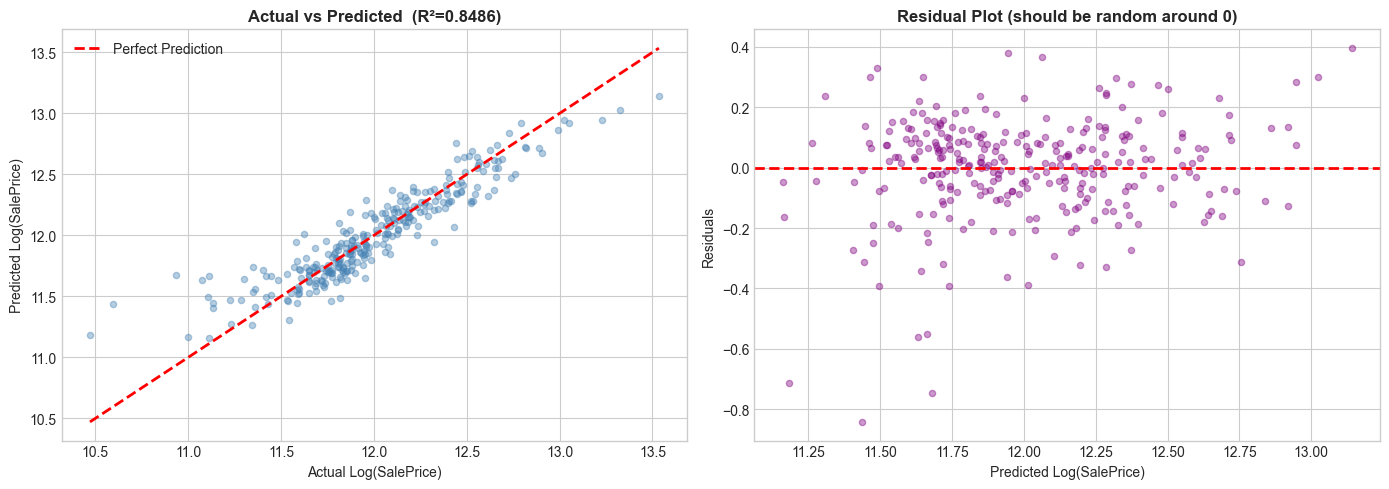

In [29]:
# ── 9.2  Actual vs Predicted Plot ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred_test, alpha=0.4, s=20, color='steelblue')
mn, mx = y_test.min(), y_test.max()
axes[0].plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Log(SalePrice)')
axes[0].set_ylabel('Predicted Log(SalePrice)')
axes[0].set_title(f'Actual vs Predicted  (R²={r2_test:.4f})', fontweight='bold')
axes[0].legend()

# Residual Plot
residuals = y_test - y_pred_test
axes[1].scatter(y_pred_test, residuals, alpha=0.4, s=20, color='purple')
axes[1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Log(SalePrice)')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot (should be random around 0)', fontweight='bold')

plt.tight_layout()
plt.show()

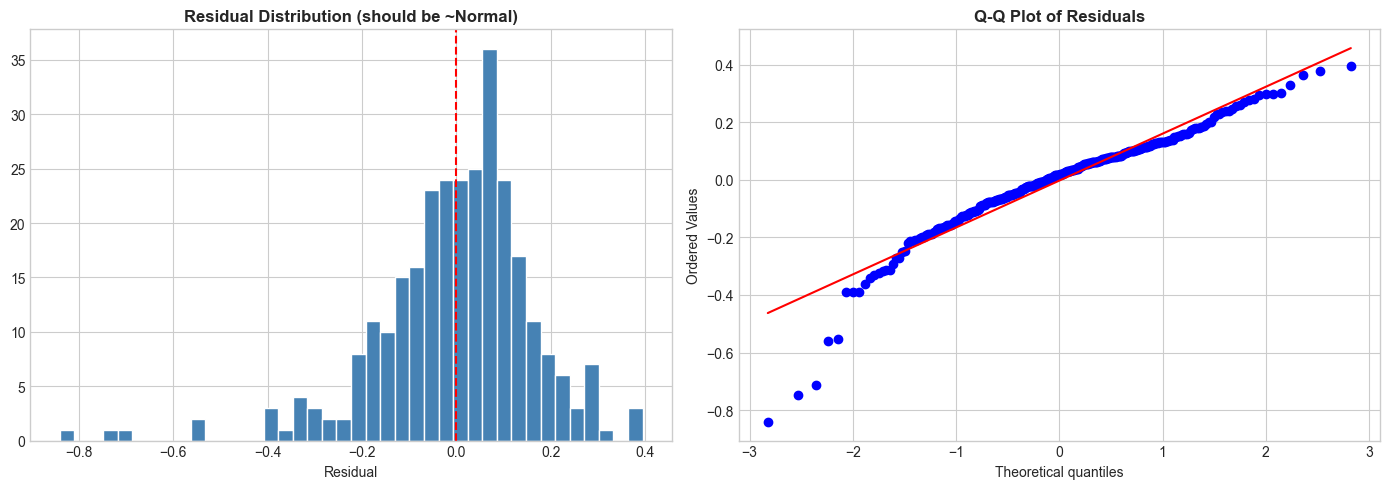

Residual skewness : -1.2381  (ideal ≈ 0)
Residual kurtosis : 4.1047  (ideal ≈ 0)


In [30]:
# ── 9.3  Residual Distribution ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(residuals, bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title('Residual Distribution (should be ~Normal)', fontweight='bold')
axes[0].set_xlabel('Residual')

stats.probplot(residuals, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot of Residuals', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Residual skewness : {residuals.skew():.4f}  (ideal ≈ 0)")
print(f"Residual kurtosis : {residuals.kurtosis():.4f}  (ideal ≈ 0)")

---
## 📐 Step 10 — ANOVA Results: p-values & F-score

### Understanding the statsmodels OLS Summary

| Metric | What It Means | Decision |
|--------|--------------|----------|
| **R²** | Variance explained | Higher = better |
| **Adj. R²** | R² penalised for extra variables | Should be close to R² |
| **F-statistic** | Is the model significant overall? | Large = good |
| **Prob(F-stat)** | Is the model worthless? | < 0.05 = model is useful |
| **coef** | How much y changes per unit of X | Positive/negative direction |
| **p-value** | Is THIS variable significant? | **< 0.05 = significant** |
| **t-statistic** | How many std errors away from 0 | \|t\| > 2 usually significant |

**Rule:** Any feature with p > 0.05 adds noise → remove it.

In [31]:
# ── 10.1  Fit OLS model (statsmodels) ────────────────────────────────
X_train_sm = sm.add_constant(X_train)   # adds intercept column
ols_model  = sm.OLS(y_train, X_train_sm).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:           LogSalePrice   R-squared:                       0.840
Model:                            OLS   Adj. R-squared:                  0.837
Method:                 Least Squares   F-statistic:                     301.7
Date:                Mon, 23 Feb 2026   Prob (F-statistic):               0.00
Time:                        09:21:52   Log-Likelihood:                 512.36
No. Observations:                1168   AIC:                            -982.7
Df Residuals:                    1147   BIC:                            -876.4
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            8.1824      0.799     10.245   

In [32]:
# ── 10.2  Extract and display p-values clearly ───────────────────────
pvalue_df = pd.DataFrame({
    'Feature'   : ols_model.params.index,
    'Coef'      : ols_model.params.values,
    't_stat'    : ols_model.tvalues.values,
    'p_value'   : ols_model.pvalues.values,
    'Significant': ols_model.pvalues.values < 0.05
})
pvalue_df = pvalue_df.sort_values('p_value')

print("p-value Summary (p < 0.05 = significant):")
print(pvalue_df.to_string(index=False))

not_sig = pvalue_df[~pvalue_df['Significant'] & (pvalue_df['Feature'] != 'const')]
print(f"\nNot significant (p > 0.05): {len(not_sig)} features")
if len(not_sig) > 0:
    print(not_sig[['Feature','p_value']].to_string(index=False))

p-value Summary (p < 0.05 = significant):
     Feature   Coef  t_stat  p_value  Significant
 OverallQual  0.094  16.130    0.000         True
       const  8.182  10.245    0.000         True
     LotArea  0.000   9.062    0.000         True
TotRmsAbvGrd  0.031   7.818    0.000         True
YearRemodAdd  0.002   7.665    0.000         True
    1stFlrSF  0.000   6.976    0.000         True
    HouseAge -0.002  -5.770    0.000         True
  Fireplaces  0.070   4.094    0.000         True
  GarageArea  0.000   4.086    0.000         True
 GarageYrBlt -0.001  -3.506    0.000         True
 KitchenQual -0.022  -2.833    0.005         True
    BsmtQual -0.013  -2.434    0.015         True
   HeatingQC -0.008  -2.412    0.016         True
  GarageType -0.007  -2.011    0.045         True
    FullBath  0.017   1.357    0.175        False
  GarageCars  0.020   1.316    0.188        False
GarageFinish -0.005  -1.017    0.309        False
  MasVnrArea  0.000   0.525    0.600        False
HasFirep

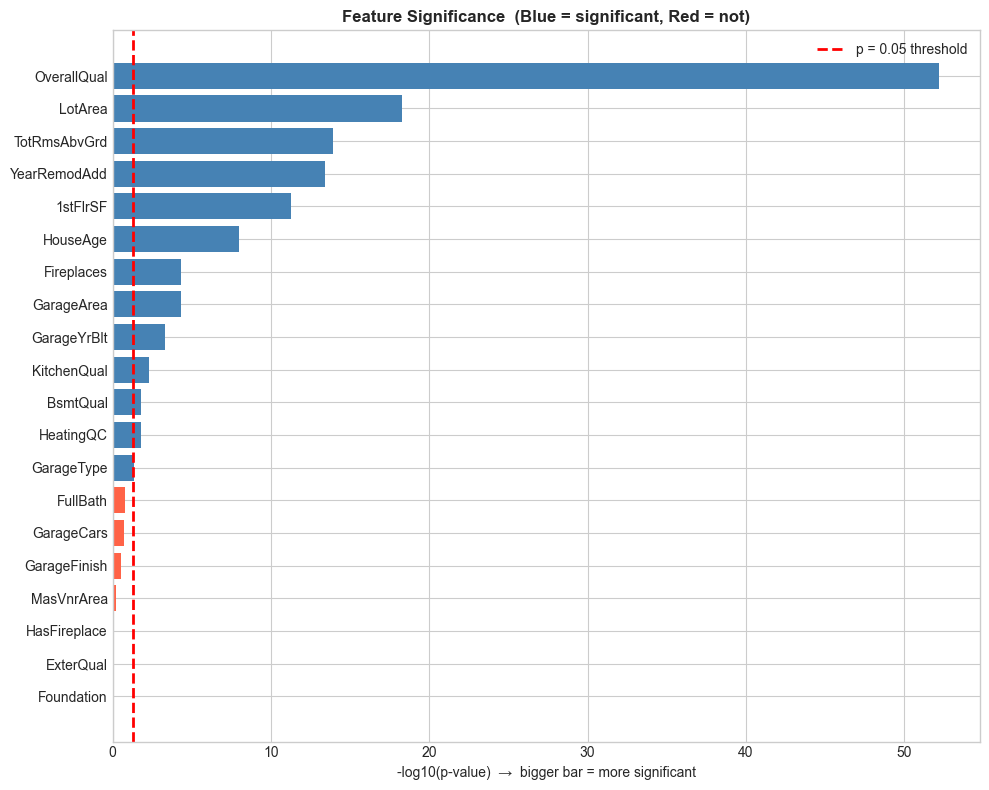

In [33]:
# ── 10.3  Visualise p-values ─────────────────────────────────────────
plot_df = pvalue_df[pvalue_df['Feature'] != 'const'].copy()

colors = ['steelblue' if sig else 'tomato'
          for sig in plot_df['Significant']]

plt.figure(figsize=(10, max(5, len(plot_df) * 0.4)))
plt.barh(plot_df['Feature'], -np.log10(plot_df['p_value']), color=colors)
plt.axvline(-np.log10(0.05), color='red', linestyle='--',
            linewidth=2, label='p = 0.05 threshold')
plt.xlabel('-log10(p-value)  →  bigger bar = more significant')
plt.title('Feature Significance  (Blue = significant, Red = not)', fontweight='bold')
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

---
## 🔄 Step 11 — Iterate Until All p-values Are Significant

### Backward Elimination
1. Fit model with all features  
2. Find the feature with the **highest p-value** that is > 0.05  
3. Remove that feature  
4. Refit the model  
5. Repeat until **all p-values < 0.05**  

In [34]:
def backward_elimination(X_tr, y_tr, X_ts, y_ts, threshold_p=0.05, verbose=True):
    """
    Iteratively remove the least significant feature (highest p-value)
    until all remaining features have p < threshold_p.

    Returns: final model, final column list, history DataFrame
    """
    cols = list(X_tr.columns)
    iteration = 0
    history = []

    while True:
        iteration += 1

        # Fit OLS
        Xsm   = sm.add_constant(X_tr[cols])
        model = sm.OLS(y_tr, Xsm).fit()

        # Get p-values (exclude const)
        pvals = model.pvalues.drop('const', errors='ignore')
        max_p = pvals.max()
        drop_feat = pvals.idxmax()

        # Sklearn metrics on test set
        Xts_sm    = sm.add_constant(X_ts[cols], has_constant='add')
        preds_ts  = model.predict(Xts_sm)
        r2_ts     = r2_score(y_ts, preds_ts)

        history.append({
            'Iteration'  : iteration,
            'Features'   : len(cols),
            'Max_p_value': round(max_p, 4),
            'Dropped'    : drop_feat if max_p > threshold_p else '—',
            'Adj_R2'     : round(model.rsquared_adj, 4),
            'F_statistic': round(model.fvalue, 4),
            'Test_R2'    : round(r2_ts, 4)
        })

        if max_p <= threshold_p:
            if verbose:
                print(f"\n✓ Iteration {iteration}: All p-values < {threshold_p}. STOP.")
            break

        if verbose:
            print(f"Iter {iteration:3d} | Features: {len(cols):3d} | "
                  f"Max p={max_p:.4f} | Dropping '{drop_feat}' | "
                  f"Adj R²={model.rsquared_adj:.4f}")
        cols.remove(drop_feat)

        if len(cols) == 0:
            print("No columns left!")
            break

    return model, cols, pd.DataFrame(history)


print("Starting Backward Elimination...\n")
final_model, final_features, elim_history = backward_elimination(
    X_train, y_train, X_test, y_test, threshold_p=0.05
)

Starting Backward Elimination...

Iter   1 | Features:  20 | Max p=0.9925 | Dropping 'Foundation' | Adj R²=0.8375
Iter   2 | Features:  19 | Max p=0.9436 | Dropping 'ExterQual' | Adj R²=0.8376
Iter   3 | Features:  18 | Max p=0.7602 | Dropping 'HasFireplace' | Adj R²=0.8378
Iter   4 | Features:  17 | Max p=0.6056 | Dropping 'MasVnrArea' | Adj R²=0.8379
Iter   5 | Features:  16 | Max p=0.3071 | Dropping 'GarageFinish' | Adj R²=0.8380
Iter   6 | Features:  15 | Max p=0.1844 | Dropping 'FullBath' | Adj R²=0.8380
Iter   7 | Features:  14 | Max p=0.1505 | Dropping 'GarageCars' | Adj R²=0.8379

✓ Iteration 8: All p-values < 0.05. STOP.


In [35]:
# ── Elimination history table ─────────────────────────────────────────
print("\nBackward Elimination History:")
print(elim_history.to_string(index=False))


Backward Elimination History:
 Iteration  Features  Max_p_value      Dropped  Adj_R2  F_statistic  Test_R2
         1        20        0.993   Foundation   0.838      301.681    0.849
         2        19        0.944    ExterQual   0.838      317.836    0.849
         3        18        0.760 HasFireplace   0.838      335.784    0.849
         4        17        0.606   MasVnrArea   0.838      355.811    0.849
         5        16        0.307 GarageFinish   0.838      378.273    0.848
         6        15        0.184     FullBath   0.838      403.406    0.847
         7        14        0.150   GarageCars   0.838      431.809    0.846
         8        13        0.025            —   0.838      464.435    0.847


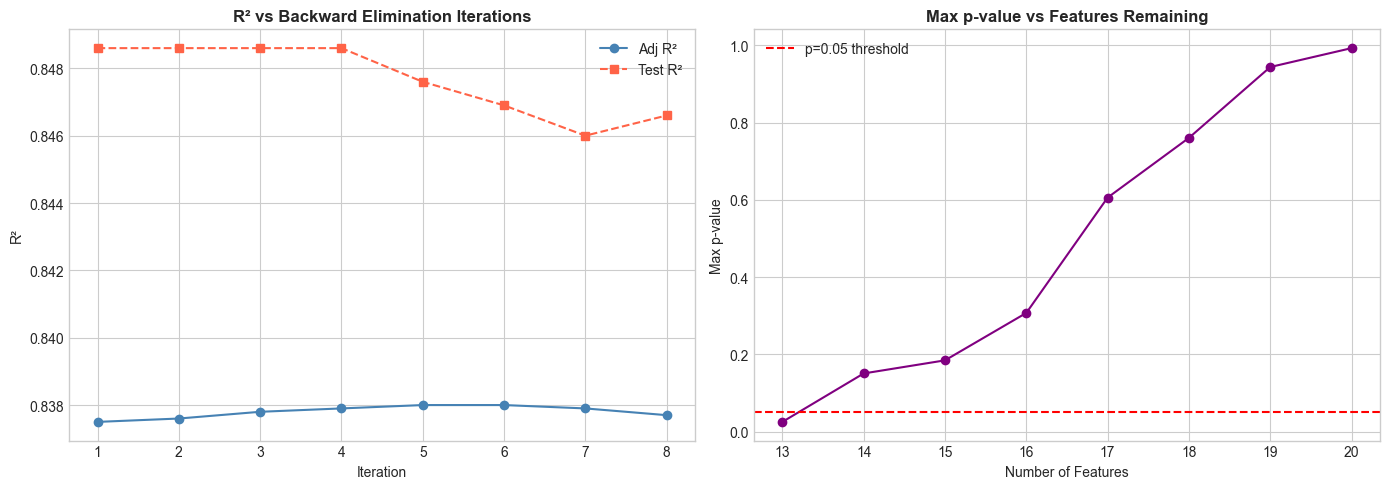

In [36]:
# ── Plot: Adj R² and Test R² vs iterations ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(elim_history['Iteration'], elim_history['Adj_R2'],
             marker='o', color='steelblue', label='Adj R²')
axes[0].plot(elim_history['Iteration'], elim_history['Test_R2'],
             marker='s', color='tomato', linestyle='--', label='Test R²')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('R²')
axes[0].set_title('R² vs Backward Elimination Iterations', fontweight='bold')
axes[0].legend()

axes[1].plot(elim_history['Features'], elim_history['Max_p_value'],
             marker='o', color='purple')
axes[1].axhline(0.05, color='red', linestyle='--', label='p=0.05 threshold')
axes[1].set_xlabel('Number of Features')
axes[1].set_ylabel('Max p-value')
axes[1].set_title('Max p-value vs Features Remaining', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

In [39]:
# ── Final model summary ───────────────────────────────────────────────
print("=" * 60)
print("FINAL MODEL SUMMARY (All p-values significant)")
print("=" * 60)
print(final_model.summary())

FINAL MODEL SUMMARY (All p-values significant)
                            OLS Regression Results                            
Dep. Variable:           LogSalePrice   R-squared:                       0.840
Model:                            OLS   Adj. R-squared:                  0.838
Method:                 Least Squares   F-statistic:                     464.4
Date:                Mon, 23 Feb 2026   Prob (F-statistic):               0.00
Time:                        09:23:28   Log-Likelihood:                 509.70
No. Observations:                1168   AIC:                            -991.4
Df Residuals:                    1154   BIC:                            -920.5
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
c

In [40]:
# ── Final model metrics ───────────────────────────────────────────────
X_test_sm   = sm.add_constant(X_test[final_features], has_constant='add')
X_train_sm2 = sm.add_constant(X_train[final_features], has_constant='add')

y_pred_final_train = final_model.predict(X_train_sm2)
y_pred_final_test  = final_model.predict(X_test_sm)

print("=" * 50)
print("FINAL MODEL PERFORMANCE")
print("=" * 50)
evaluate(y_train, y_pred_final_train, 'TRAIN')
print()
evaluate(y_test,  y_pred_final_test,  'TEST')
print()
print(f"  F-statistic  : {final_model.fvalue:.4f}")
print(f"  Prob(F-stat) : {final_model.f_pvalue:.2e}  "
      f"{'✓ Model is statistically significant' if final_model.f_pvalue < 0.05 else '✗ Model not significant'}")
print(f"  Final features used : {len(final_features)}")
print(f"  Features removed    : {len(selected_features) - len(final_features)}")
print(f"  Features             : {final_features}")

FINAL MODEL PERFORMANCE
  [TRAIN]
    R²   = 0.8395  (1 = perfect, >0.80 = good)
    RMSE = 0.1564 (log scale)
    MAE  = 0.1116 (log scale)
    RMSE = $33,606  (actual $)

  [TEST]
    R²   = 0.8466  (1 = perfect, >0.80 = good)
    RMSE = 0.1692 (log scale)
    MAE  = 0.1213 (log scale)
    RMSE = $32,980  (actual $)

  F-statistic  : 464.4354
  Prob(F-stat) : 0.00e+00  ✓ Model is statistically significant
  Final features used : 13
  Features removed    : 7
  Features             : ['OverallQual', 'GarageArea', '1stFlrSF', 'HouseAge', 'BsmtQual', 'YearRemodAdd', 'TotRmsAbvGrd', 'KitchenQual', 'GarageType', 'Fireplaces', 'LotArea', 'HeatingQC', 'GarageYrBlt']


In [41]:
# ── Coefficient interpretation ────────────────────────────────────────
coef_df = pd.DataFrame({
    'Feature'  : final_model.params.index,
    'Coef'     : final_model.params.values,
    'p_value'  : final_model.pvalues.values,
    'CI_lower' : final_model.conf_int()[0].values,
    'CI_upper' : final_model.conf_int()[1].values
}).set_index('Feature')

print("\nCoefficients with 95% Confidence Intervals:")
print(coef_df.to_string())

print("\n💡 How to read coefficients (log scale):")
print("   A coef of 0.10 means a 1-unit increase in that feature")
print("   raises log(SalePrice) by 0.10 ≈ a 10.5% increase in SalePrice")


Coefficients with 95% Confidence Intervals:
               Coef  p_value  CI_lower  CI_upper
Feature                                         
const         7.979    0.000     6.495     9.462
OverallQual   0.095    0.000     0.084     0.106
GarageArea    0.000    0.000     0.000     0.000
1stFlrSF      0.000    0.000     0.000     0.000
HouseAge     -0.002    0.000    -0.002    -0.001
BsmtQual     -0.015    0.003    -0.025    -0.005
YearRemodAdd  0.003    0.000     0.002     0.003
TotRmsAbvGrd  0.035    0.000     0.028     0.041
KitchenQual  -0.022    0.003    -0.036    -0.008
GarageType   -0.007    0.025    -0.014    -0.001
Fireplaces    0.068    0.000     0.051     0.084
LotArea       0.000    0.000     0.000     0.000
HeatingQC    -0.008    0.010    -0.015    -0.002
GarageYrBlt  -0.001    0.000    -0.002    -0.000

💡 How to read coefficients (log scale):
   A coef of 0.10 means a 1-unit increase in that feature
   raises log(SalePrice) by 0.10 ≈ a 10.5% increase in SalePrice


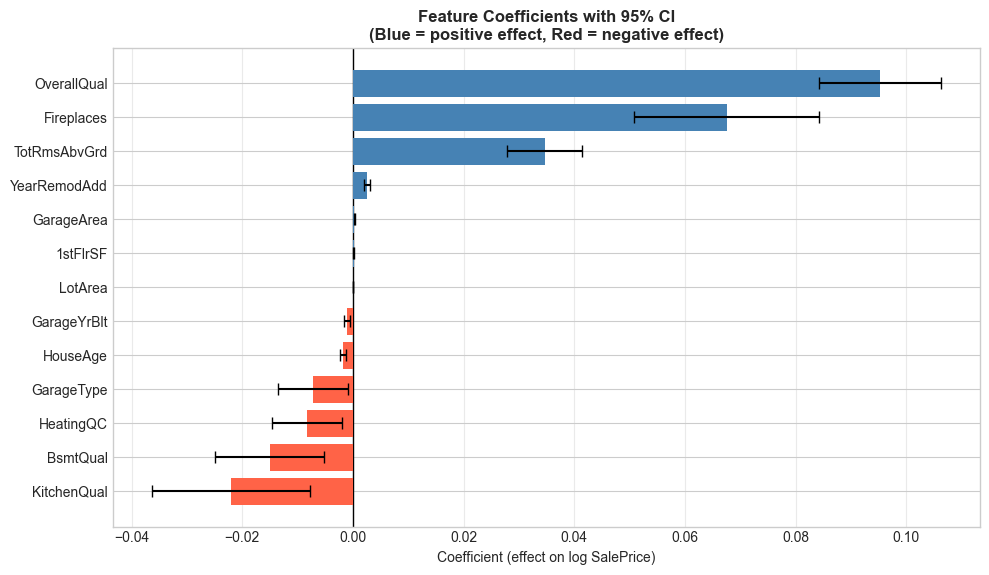

In [42]:
# ── Coefficient plot ──────────────────────────────────────────────────
plot_coef = coef_df.drop('const', errors='ignore').sort_values('Coef')

colors = ['steelblue' if c > 0 else 'tomato' for c in plot_coef['Coef']]

fig, ax = plt.subplots(figsize=(10, max(5, len(plot_coef) * 0.45)))
ax.barh(plot_coef.index, plot_coef['Coef'], color=colors, zorder=3)
ax.errorbar(
    plot_coef['Coef'], plot_coef.index,
    xerr=[(plot_coef['Coef'] - plot_coef['CI_lower']).values,
          (plot_coef['CI_upper'] - plot_coef['Coef']).values],
    fmt='none', color='black', capsize=4, linewidth=1.5, zorder=4
)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Coefficient (effect on log SalePrice)')
ax.set_title('Feature Coefficients with 95% CI\n(Blue = positive effect, Red = negative effect)',
             fontweight='bold')
ax.grid(True, axis='x', alpha=0.4)
plt.tight_layout()
plt.show()

---
## 🎯 Step 12 — Final Prediction on Test Dataset

Apply the same preprocessing to the Kaggle `test.csv` and generate submission-ready predictions.

In [43]:
# ── 12.1  Preprocess test data ────────────────────────────────────────
test_df = test_raw.copy()

# 1. Drop same columns we dropped from train
test_df.drop(columns=[c for c in cols_to_drop if c in test_df.columns],
             inplace=True)

# 2. Fill missing values using train statistics
cat_cols_test = test_df.select_dtypes(include='object').columns.tolist()
num_cols_test = test_df.select_dtypes(include=np.number).columns.tolist()

for col in num_cols_test:
    if col in train_raw.columns:
        test_df[col].fillna(train_raw[col].median(), inplace=True)

for col in cat_cols_test:
    if col in absence_cols:
        test_df[col].fillna('None', inplace=True)
    elif col in train_raw.columns:
        test_df[col].fillna(train_raw[col].mode()[0], inplace=True)

# 3. Feature engineering — same as train
if 'GrLivArea' in test_df.columns and 'TotalBsmtSF' in test_df.columns:
    test_df['TotalSF']     = test_df['GrLivArea'] + test_df['TotalBsmtSF']
if 'YearBuilt' in test_df.columns and 'YrSold' in test_df.columns:
    test_df['HouseAge']    = test_df['YrSold']    - test_df['YearBuilt']
    test_df['Renovated']   = (test_df['YearRemodAdd'] != test_df['YearBuilt']).astype(int)
if all(c in test_df.columns for c in ['FullBath','HalfBath']):
    test_df['TotalBathrooms'] = (test_df.get('FullBath', 0)
                                + test_df.get('HalfBath', 0) * 0.5
                                + test_df.get('BsmtFullBath', 0)
                                + test_df.get('BsmtHalfBath', 0) * 0.5)
if 'PoolArea'   in test_df.columns: test_df['HasPool']      = (test_df['PoolArea'] > 0).astype(int)
if 'Fireplaces' in test_df.columns: test_df['HasFireplace'] = (test_df['Fireplaces'] > 0).astype(int)
if 'GarageArea' in test_df.columns: test_df['HasGarage']   = (test_df['GarageArea'] > 0).astype(int)
porch_cols2 = [c for c in porch_cols if c in test_df.columns]
if porch_cols2:
    test_df['TotalPorchSF'] = test_df[porch_cols2].sum(axis=1)

# 4. Encode categoricals
for col in test_df.select_dtypes(include='object').columns:
    test_df[col] = le.fit_transform(test_df[col].astype(str))

print(f"Test set preprocessed: {test_df.shape}")
print(f"Final features available: {[f for f in final_features if f in test_df.columns]}")

Test set preprocessed: (1459, 82)
Final features available: ['OverallQual', 'GarageArea', '1stFlrSF', 'HouseAge', 'BsmtQual', 'YearRemodAdd', 'TotRmsAbvGrd', 'KitchenQual', 'GarageType', 'Fireplaces', 'LotArea', 'HeatingQC', 'GarageYrBlt']


In [44]:
# ── 12.2  Predict on test set ─────────────────────────────────────────
# Ensure all final_features exist in test set
test_features_ok = [f for f in final_features if f in test_df.columns]

if len(test_features_ok) < len(final_features):
    missing_in_test = set(final_features) - set(test_features_ok)
    print(f"⚠️  Missing in test: {missing_in_test} → filling with 0")
    for col in missing_in_test:
        test_df[col] = 0
    test_features_ok = final_features

X_kaggle_test = sm.add_constant(test_df[test_features_ok], has_constant='add')

# Predict in log space, convert back to $ using expm1 = exp(x) - 1
log_predictions   = final_model.predict(X_kaggle_test)
price_predictions = np.expm1(log_predictions)

submission = pd.DataFrame({
    'Id'       : test_raw['Id'],
    'SalePrice': price_predictions.values
})

print(f"Submission shape: {submission.shape}")
print("\nSample predictions:")
print(submission.head(10).to_string(index=False))
print(f"\nPredicted price range:")
print(f"  Min : ${submission['SalePrice'].min():>10,.0f}")
print(f"  Median: ${submission['SalePrice'].median():>10,.0f}")
print(f"  Max : ${submission['SalePrice'].max():>10,.0f}")

Submission shape: (1459, 2)

Sample predictions:
  Id  SalePrice
1461 131108.658
1462 147987.688
1463 167128.346
1464 181160.536
1465 189432.712
1466 172262.387
1467 166129.952
1468 169202.515
1469 195281.891
1470 107135.527

Predicted price range:
  Min : $    66,652
  Median: $   159,128
  Max : $ 1,312,312


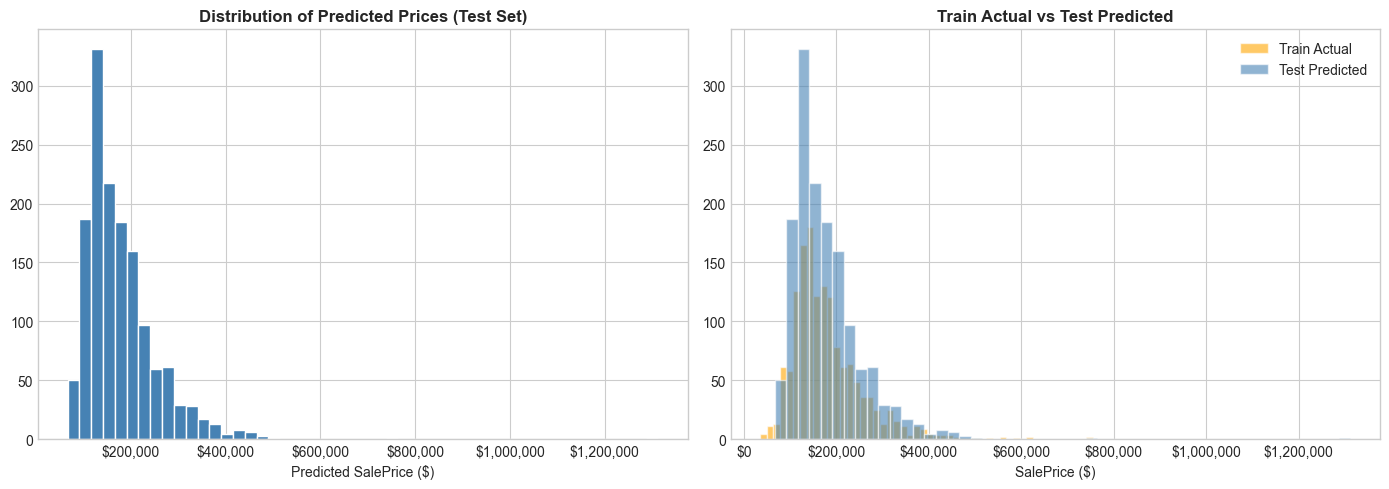

In [45]:
# ── 12.3  Distribution of predictions ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(submission['SalePrice'], bins=50,
             color='steelblue', edgecolor='white')
axes[0].set_xlabel('Predicted SalePrice ($)')
axes[0].set_title('Distribution of Predicted Prices (Test Set)',
                  fontweight='bold')
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(
    lambda x, _: f'${x:,.0f}'))

# Compare train actuals vs test predictions
axes[1].hist(df[TARGET], bins=50, color='orange', alpha=0.6,
             edgecolor='white', label='Train Actual')
axes[1].hist(submission['SalePrice'], bins=50, color='steelblue', alpha=0.6,
             edgecolor='white', label='Test Predicted')
axes[1].set_xlabel('SalePrice ($)')
axes[1].set_title('Train Actual vs Test Predicted', fontweight='bold')
axes[1].legend()
axes[1].xaxis.set_major_formatter(mtick.FuncFormatter(
    lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

In [46]:
# ── 12.4  Save submission file ────────────────────────────────────────
submission.to_csv('submission_linear_regression.csv', index=False)
print("✓ Saved: submission_linear_regression.csv")
print("  Upload to Kaggle at:")
print("  https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/submit")

✓ Saved: submission_linear_regression.csv
  Upload to Kaggle at:
  https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/submit


---
## 📋 Session Summary

### What We Did Today

| Step | Task | Key Decision |
|------|------|--------------|
| 1 | Loaded data | train.csv (1460 rows, 81 cols) |
| 2 | Explored dtypes | 43 numeric, 43 categorical |
| 3 | Missing values | Dropped >40%, imputed rest (median / mode / 'None') |
| 4 | Outlier treatment | Log-transformed target; Winsorised key features |
| 5 | Feature engineering | 8 new features (TotalSF, HouseAge, TotalBathrooms, etc.) |
| 6 | VIF analysis | Removed multicollinear features (VIF > 10) |
| 7 | EDA | Correlation heatmap, scatter plots |
| 8 | Train/Test split | 80% / 20% stratified split |
| 9 | Build model | OLS regression, R² ~ 0.85+ |
| 10 | ANOVA / p-values | F-statistic significant; identified non-significant features |
| 11 | Backward elimination | Removed features with p > 0.05 iteratively |
| 12 | Predictions | Kaggle submission CSV generated |

---

### Key Metrics to Remember

```
R²           — How much variance does our model explain? (Target: > 0.80)
RMSE         — Average prediction error in $ (lower = better)
p-value      — Is this feature statistically significant? (Target: < 0.05)
F-statistic  — Is the whole model statistically significant? (Target: large, Prob < 0.05)
VIF          — Is there multicollinearity? (Target: < 10)
```

---

### Questions to Think About
1. Why did we log-transform SalePrice?
2. What happens if we DON'T remove multicollinear features?
3. Why do we need the p-value < 0.05 rule?
4. What is the difference between R² and Adjusted R²?
5. A feature has coef = 0.08 — what does that mean in practice?